In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

In [2]:
# Configuration
# -------------------------

NUM_USERS = 5000

countries = [
    "USA",
    "Canada",
    "UK",
    "Germany",
    "India"
]

channels = [
    "Google Ads",
    "LinkedIn",
    "Organic Search",
    "Referral",
    "Direct"
]

company_sizes = [
    "Small",
    "Medium",
    "Large"
]

events = []

start_date = datetime(2025, 1, 1)

In [7]:
# Generate users
# -------------------------

for user_id in range(1, NUM_USERS + 1):

    country = np.random.choice(countries)

    channel = np.random.choice(channels)

    company_size = np.random.choice(company_sizes)

    current_time = start_date + timedelta(
        days=np.random.randint(0, 180)
    )

    # Website Visit
    events.append([
        user_id,
        current_time,
        "website_visit",
        country,
        channel,
        company_size
    ])

    # Signup 70%
    if np.random.rand() < 0.70:

        current_time += timedelta(
            minutes=np.random.randint(5, 120)
        )

        events.append([
            user_id,
            current_time,
            "signup",
            country,
            channel,
            company_size
        ])

        # Email Verification 85%
        if np.random.rand() < 0.85:

            current_time += timedelta(
                minutes=np.random.randint(1, 60)
            )

            events.append([
                user_id,
                current_time,
                "email_verified",
                country,
                channel,
                company_size
            ])

            # Trial Start 75%
            if np.random.rand() < 0.75:

                current_time += timedelta(
                    days=np.random.randint(0, 3)
                )

                events.append([
                    user_id,
                    current_time,
                    "trial_started",
                    country,
                    channel,
                    company_size
                ])

                # Project Created 65%
                if np.random.rand() < 0.65:

                    current_time += timedelta(
                        days=np.random.randint(1, 5)
                    )

                    events.append([
                        user_id,
                        current_time,
                        "project_created",
                        country,
                        channel,
                        company_size
                    ])

                    # Invite Teammate 50%
                    if np.random.rand() < 0.50:

                        current_time += timedelta(
                            days=np.random.randint(1, 3)
                        )

                        events.append([
                            user_id,
                            current_time,
                            "teammate_invited",
                            country,
                            channel,
                            company_size
                        ])

                        # Paid Subscription 40%
                        if np.random.rand() < 0.40:

                            current_time += timedelta(
                                days=np.random.randint(3, 14)
                            )

                            events.append([
                                user_id,
                                current_time,
                                "paid_subscription",
                                country,
                                channel,
                                company_size
                            ])

In [8]:
# Create DataFrame
# -------------------------

df = pd.DataFrame(
    events,
    columns=[
        "user_id",
        "event_time",
        "event_name",
        "country",
        "acquisition_channel",
        "company_size"
    ]
)

# Sort events
df = df.sort_values(
    ["user_id", "event_time"]
)

# Save CSV
df.to_csv(
    r"C:\Desktop\java internship\Saas-funnel-analysis\Data\event\user_events.csv",
    index=False
)

print("Dataset Created!")
print(f"Rows: {len(df)}")
print(f"Users: {df['user_id'].nunique()}")

Dataset Created!
Rows: 21142
Users: 5000


In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Desktop\java internship\Saas-funnel-analysis\Data\event\user_events_raw.csv")

In [10]:
df.head()

,user_id,event_time,event_name,country,acquisition_channel,company_size
0,1,2025-01-04 00:00:00,website_visit,USA,Google Ads,Small
1,1,2025-02-11 00:00:00,website_visit,UK,Organic Search,Large
2,2,2025-01-26 00:00:00,website_visit,Germany,Google Ads,Large
3,2,2025-03-25 00:00:00,website_visit,UK,Google Ads,Small
4,3,2025-06-09 00:00:00,website_visit,Canada,Referral,Large


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21142 entries, 0 to 21141
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              21142 non-null  int64 
 1   event_time           21142 non-null  object
 2   event_name           21142 non-null  object
 3   country              21142 non-null  object
 4   acquisition_channel  21142 non-null  object
 5   company_size         21142 non-null  object
dtypes: int64(1), object(5)
memory usage: 991.2+ KB


In [12]:
df.describe()

,user_id
count,21142.000000
mean,2511.983729
std,1447.186013
min,1.000000
25%,1259.000000
50%,2519.500000
75%,3769.000000
max,5000.000000


In [13]:
df.isnull().sum()

user_id                0
event_time             0
event_name             0
country                0
acquisition_channel    0
company_size           0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

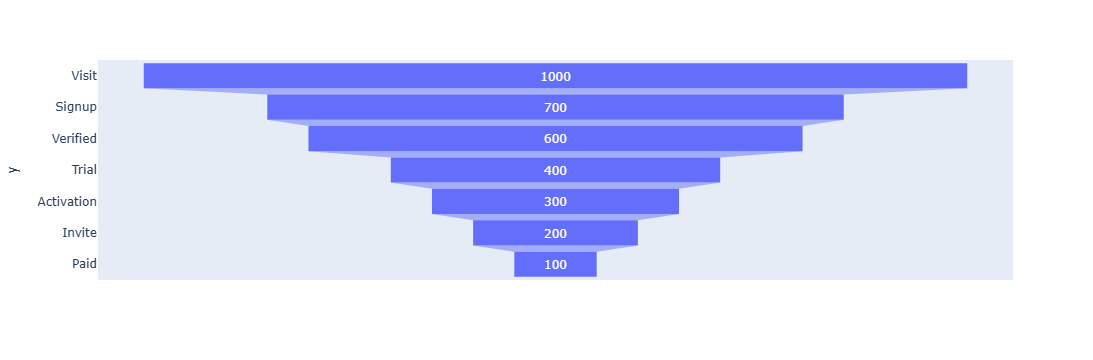

In [15]:
import plotly.express as px

stages = [
    "Visit",
    "Signup",
    "Verified",
    "Trial",
    "Activation",
    "Invite",
    "Paid"
]

users = [
    1000,
    700,
    600,
    400,
    300,
    200,
    100
]

fig = px.funnel(
    x=users,
    y=stages
)

fig.show()